# Ejercicio 1 — Programación Genética para un decodificador de 7 segmentos

**Objetivo:** usar Programación Genética (PG) para encontrar expresiones lógicas que controlen los 7 segmentos de un display.

Se empleó la librería **DEAP** y se evolucionará una expresión lógica por cada segmento: a, b, c, d, e, f, g.


## 1. Instalar e importar las librerías

DEAP permite implementar Programación Genética representando cada individuo mediante un árbol.

In [10]:
!pip -q install deap

In [11]:
import operator
import random
import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, gp, algorithms

## 2. Tabla de verdad del display de 7 segmentos

Las entradas BCD serán: A, B, C, y D.

donde `A` es el bit más significativo y `D` el menos significativo.

Cada salida indica si un segmento debe encenderse (1) o apagarse (0).

Se usarán únicamente los dígitos decimales del 0 al 9.

In [12]:
# Segmentos en orden: a, b, c, d, e, f, g
segmentos = {
    0: (1,1,1,1,1,1,0),
    1: (0,1,1,0,0,0,0),
    2: (1,1,0,1,1,0,1),
    3: (1,1,1,1,0,0,1),
    4: (0,1,1,0,0,1,1),
    5: (1,0,1,1,0,1,1),
    6: (1,0,1,1,1,1,1),
    7: (1,1,1,0,0,0,0),
    8: (1,1,1,1,1,1,1),
    9: (1,1,1,1,0,1,1)
}

datos = []

for numero in range(10):
    A = (numero >> 3) & 1
    B = (numero >> 2) & 1
    C = (numero >> 1) & 1
    D = numero & 1
    datos.append((A, B, C, D, *segmentos[numero]))

print(" A B C D | a b c d e f g")
for fila in datos:
    print(*fila[:4], "|", *fila[4:])

 A B C D | a b c d e f g
0 0 0 0 | 1 1 1 1 1 1 0
0 0 0 1 | 0 1 1 0 0 0 0
0 0 1 0 | 1 1 0 1 1 0 1
0 0 1 1 | 1 1 1 1 0 0 1
0 1 0 0 | 0 1 1 0 0 1 1
0 1 0 1 | 1 0 1 1 0 1 1
0 1 1 0 | 1 0 1 1 1 1 1
0 1 1 1 | 1 1 1 0 0 0 0
1 0 0 0 | 1 1 1 1 1 1 1
1 0 0 1 | 1 1 1 1 0 1 1


## 3. Definir los elementos de la Programación Genética

### Terminales

Siguiendo el documento, los terminales corresponden a las hojas del árbol. En este problema son las entradas:

$$
T=\{A,B,C,D\}
$$

### Funciones primitivas

Como se trata de un circuito lógico, se utilizarán únicamente tres operaciones booleanas:

$$
F=\{\mathrm{AND},\mathrm{OR},\mathrm{NOT}\}
$$

Así, la PG buscará automáticamente combinaciones de estas operaciones y de las cuatro entradas.

In [13]:
# Funciones lógicas
def AND(x, y):
    return bool(x) and bool(y)

def OR(x, y):
    return bool(x) or bool(y)

def NOT(x):
    return not bool(x)

# Conjunto de primitivas
pset = gp.PrimitiveSet("MAIN", 4)

pset.addPrimitive(AND, 2)
pset.addPrimitive(OR, 2)
pset.addPrimitive(NOT, 1)

pset.renameArguments(ARG0="A", ARG1="B", ARG2="C", ARG3="D")

## 4. Función de aptitud

Para cada segmento se comparará la salida obtenida por el programa con la salida correcta de la tabla.

Como existen 10 dígitos, definimos:

$$
\text{Aptitud}=\sum_{i=0}^{9} I(\hat{y}_i=y_i)
$$

donde:

- $y_i$ es la salida correcta.
- $\hat{y}_i$ es la salida producida por el árbol.
- $I$ vale `1` cuando ambas coinciden y `0` cuando no coinciden.

Por lo tanto:

$$
0\leq \text{Aptitud}\leq10
$$

Una aptitud de **10** significa que la expresión reproduce correctamente todos los casos del segmento.

In [14]:
# DEAP necesita definir el tipo de fitness y el tipo de individuo.
# Se comprueba primero para permitir volver a ejecutar la celda.

if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))

if not hasattr(creator, "Individual"):
    creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

## 5. Configurar la evolución

Se utilizarán:

- Población: **100 individuos**
- Máximo: **50 generaciones**
- Probabilidad de cruce: **0.7**
- Probabilidad de mutación: **0.01**
- Selección por torneo
- El mejor individuo se conserva mediante un `HallOfFame`

El documento utiliza como valores de referencia una probabilidad de cruce de `0.7`, mutación de `0.01` y población de `100`. Para hacer el ejercicio más rápido en Colab limitamos la ejecución a 50 generaciones y además terminamos anticipadamente cuando se alcanza la aptitud perfecta.

In [15]:
def evolucionar_segmento(indice_segmento):

    toolbox = base.Toolbox()

    # Árboles iniciales pequeños
    toolbox.register(
        "expr",
        gp.genHalfAndHalf,
        pset=pset,
        min_=1,
        max_=3
    )

    toolbox.register(
        "individual",
        tools.initIterate,
        creator.Individual,
        toolbox.expr
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register("compile", gp.compile, pset=pset)

    # Función de aptitud
    def evaluar(individuo):
        programa = toolbox.compile(expr=individuo)
        aciertos = 0

        for fila in datos:
            A, B, C, D = fila[:4]
            esperado = fila[4 + indice_segmento]

            obtenido = int(programa(A, B, C, D))
            aciertos += (obtenido == esperado)

        return (aciertos,)

    toolbox.register("evaluate", evaluar)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", gp.cxOnePoint)

    toolbox.register(
        "expr_mut",
        gp.genFull,
        min_=0,
        max_=2
    )

    toolbox.register(
        "mutate",
        gp.mutUniform,
        expr=toolbox.expr_mut,
        pset=pset
    )

    # Evitar crecimiento excesivo de los árboles
    toolbox.decorate(
        "mate",
        gp.staticLimit(key=operator.attrgetter("height"), max_value=8)
    )

    toolbox.decorate(
        "mutate",
        gp.staticLimit(key=operator.attrgetter("height"), max_value=8)
    )

    poblacion = toolbox.population(n=100)
    hof = tools.HallOfFame(1)

    estadisticas = tools.Statistics(lambda ind: ind.fitness.values[0])
    estadisticas.register("max", np.max)

    historial = []

    # Evaluar población inicial
    invalidos = [ind for ind in poblacion if not ind.fitness.valid]
    for ind, fit in zip(invalidos, map(toolbox.evaluate, invalidos)):
        ind.fitness.values = fit

    hof.update(poblacion)
    historial.append(max(ind.fitness.values[0] for ind in poblacion))

    # Evolución
    for generacion in range(1, 51):

        descendencia = algorithms.varAnd(
            poblacion,
            toolbox,
            cxpb=0.7,
            mutpb=0.01
        )

        invalidos = [ind for ind in descendencia if not ind.fitness.valid]

        for ind, fit in zip(invalidos, map(toolbox.evaluate, invalidos)):
            ind.fitness.values = fit

        poblacion = toolbox.select(descendencia, len(poblacion))
        hof.update(poblacion)

        mejor = hof[0].fitness.values[0]
        historial.append(mejor)

        # Solución perfecta
        if mejor == 10:
            break

    return hof[0], historial

## 6. Evolucionar los siete segmentos

Se repite exactamente el mismo procedimiento para cada salida:

$$
a,\;b,\;c,\;d,\;e,\;f,\;g
$$

Como la población se genera aleatoriamente, las expresiones encontradas pueden cambiar entre ejecuciones. Esto es normal en un algoritmo evolutivo.

In [16]:
nombres = ["a", "b", "c", "d", "e", "f", "g"]

soluciones = {}
historias = {}

for i, nombre in enumerate(nombres):

    mejor, historial = evolucionar_segmento(i)

    soluciones[nombre] = mejor
    historias[nombre] = historial

    print(f"Segmento {nombre}")
    print("Expresión:", mejor)
    print("Aptitud:", mejor.fitness.values[0], "/ 10")
    print("-" * 50)

Segmento a
Expresión: OR(AND(NOT(D), NOT(B)), AND(OR(C, B), OR(C, D)))
Aptitud: 9.0 / 10
--------------------------------------------------
Segmento b
Expresión: OR(D, NOT(OR(AND(A, C), AND(B, C))))
Aptitud: 9.0 / 10
--------------------------------------------------
Segmento c
Expresión: OR(NOT(C), OR(D, AND(B, NOT(D))))
Aptitud: 10.0 / 10
--------------------------------------------------
Segmento d
Expresión: OR(OR(C, OR(OR(A, AND(D, OR(OR(C, B), C))), C)), NOT(OR(OR(C, B), D)))
Aptitud: 9.0 / 10
--------------------------------------------------
Segmento e
Expresión: NOT(D)
Aptitud: 9.0 / 10
--------------------------------------------------
Segmento f
Expresión: OR(A, B)
Aptitud: 8.0 / 10
--------------------------------------------------
Segmento g
Expresión: OR(A, OR(B, AND(C, C)))
Aptitud: 9.0 / 10
--------------------------------------------------


## 7. Verificar las soluciones

Ahora comprobamos las siete expresiones con todos los dígitos.

Una solución completa será correcta cuando las siete salidas calculadas coincidan con las salidas esperadas para los números del `0` al `9`.

In [17]:
funciones = {
    nombre: gp.compile(expr=soluciones[nombre], pset=pset)
    for nombre in nombres
}

print("Número | Esperado       | Calculado      | Correcto")
print("-" * 58)

correctos = 0

for numero, fila in enumerate(datos):

    A, B, C, D = fila[:4]
    esperado = tuple(fila[4:])

    calculado = tuple(
        int(funciones[n](A, B, C, D))
        for n in nombres
    )

    ok = esperado == calculado
    correctos += ok

    print(
        f"{numero:^6} | {str(esperado):14} | "
        f"{str(calculado):14} | {ok}"
    )

print()
print(f"Dígitos correctamente representados: {correctos}/10")

Número | Esperado       | Calculado      | Correcto
----------------------------------------------------------
  0    | (1, 1, 1, 1, 1, 1, 0) | (1, 1, 1, 1, 1, 0, 0) | False
  1    | (0, 1, 1, 0, 0, 0, 0) | (0, 1, 1, 0, 0, 0, 0) | True
  2    | (1, 1, 0, 1, 1, 0, 1) | (1, 1, 0, 1, 1, 0, 1) | True
  3    | (1, 1, 1, 1, 0, 0, 1) | (1, 1, 1, 1, 0, 0, 1) | True
  4    | (0, 1, 1, 0, 0, 1, 1) | (0, 1, 1, 0, 1, 1, 1) | False
  5    | (1, 0, 1, 1, 0, 1, 1) | (1, 1, 1, 1, 0, 1, 1) | False
  6    | (1, 0, 1, 1, 1, 1, 1) | (1, 0, 1, 1, 1, 1, 1) | True
  7    | (1, 1, 1, 0, 0, 0, 0) | (1, 1, 1, 1, 0, 1, 1) | False
  8    | (1, 1, 1, 1, 1, 1, 1) | (1, 1, 1, 1, 1, 1, 1) | True
  9    | (1, 1, 1, 1, 0, 1, 1) | (0, 1, 1, 1, 0, 1, 1) | False

Dígitos correctamente representados: 5/10


## 8. Evolución de la aptitud

La siguiente gráfica permite observar cómo mejora el mejor individuo a medida que avanzan las generaciones.

La aptitud máxima posible es:

$$
f_{\max}=10
$$

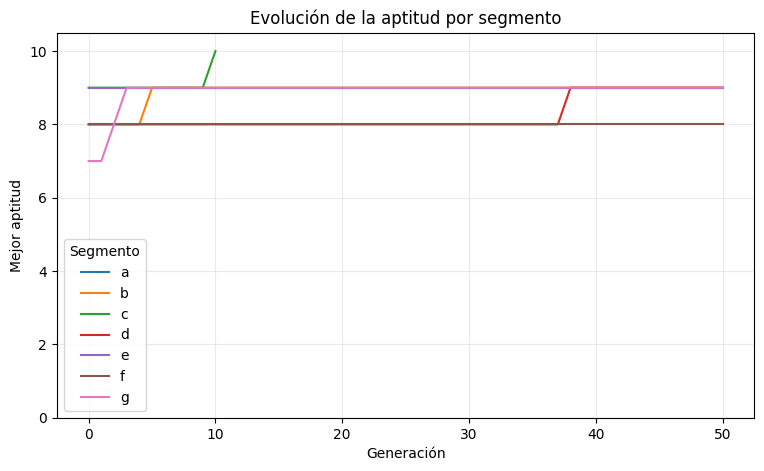

In [18]:
plt.figure(figsize=(9, 5))

for nombre in nombres:
    plt.plot(historias[nombre], label=nombre)

plt.xlabel("Generación")
plt.ylabel("Mejor aptitud")
plt.title("Evolución de la aptitud por segmento")
plt.ylim(0, 10.5)
plt.legend(title="Segmento")
plt.grid(alpha=0.25)
plt.show()